# II. Different random graph models
This chapter shows the results for when the random graph model is changed. This means that we fix the noisy opinion model with fixed parameters and experiment with the three random graph generator models. 

In [7]:
from rand_hypergraph_models import generate_general_er_hypergraph, generate_recursive_er_simplicial_complex, generate_generalized_hsbm
from analysis2 import compare_graph_models_noisy_ratios, plot_graph_model_comparison_noisy_majority_ratio, plot_graph_model_comparison_noisy_inactive_edge_ratio

In [8]:
n= 100 # number of nodes
K=100 # The number of simulations that we run for each point for each model.
steps = 500 #number discrete time steps

prob_positive_opinion= 0.5 # Probability with what a node is of opinion +1 
ER_probabilites = ER_probabilites = {2: 0.15, 3: 0.001} # Probabilities for ER hypergraph generator
SBM_probabilities = SBM_probabilities = {2: (0.25, 0.05),3: (0.0025, 0.0005)} # Probabilities for SBM hypergraph generator
p1_recursive_ER = 0.15 # Probabilities for recursive ER, 2-edge
p2_recursive_ER = 0.3 # Probabilities for recursive ER, 3-edge
noisy_probabilities = {"p": 0.5, "q": 0.5} # Probabilities for noisy voter model

In [10]:
generator_specs = [
    (
        "General ER",
        generate_general_er_hypergraph,
        {
            "n": n,
            "probabilities": ER_probabilites
        }
    ),
    (
        "Recursive ER",
        generate_recursive_er_simplicial_complex,
        {
            "n": n,
            "p1": p1_recursive_ER,
            "p2": p2_recursive_ER
        }
    ),
    (
        "HSBM",
        generate_generalized_hsbm,
        {
            "n": n,
            "probabilities": SBM_probabilities
        }
    )
]

In [11]:
results = compare_graph_models_noisy_ratios(
    generator_specs=generator_specs,
    opinion_kwargs={"prob_positive": prob_positive_opinion},
    noisy_kwargs=noisy_probabilities,
    max_steps=steps,
    K=K,
    base_seed=123
)

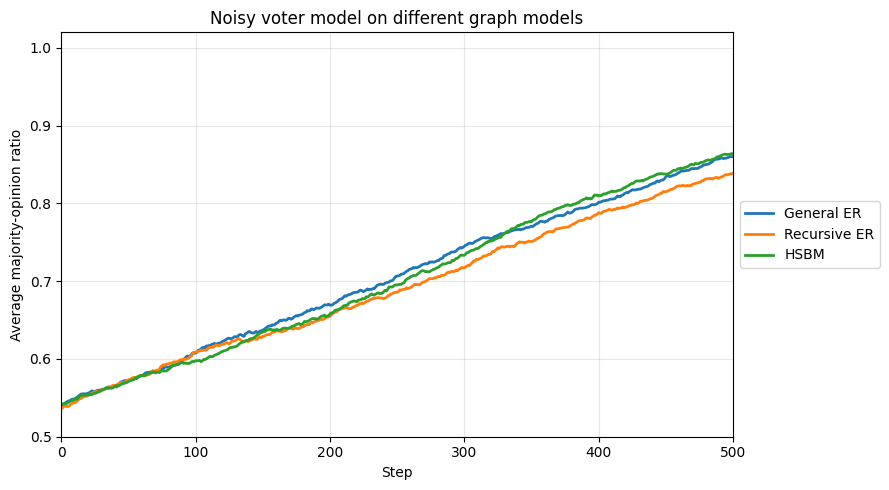

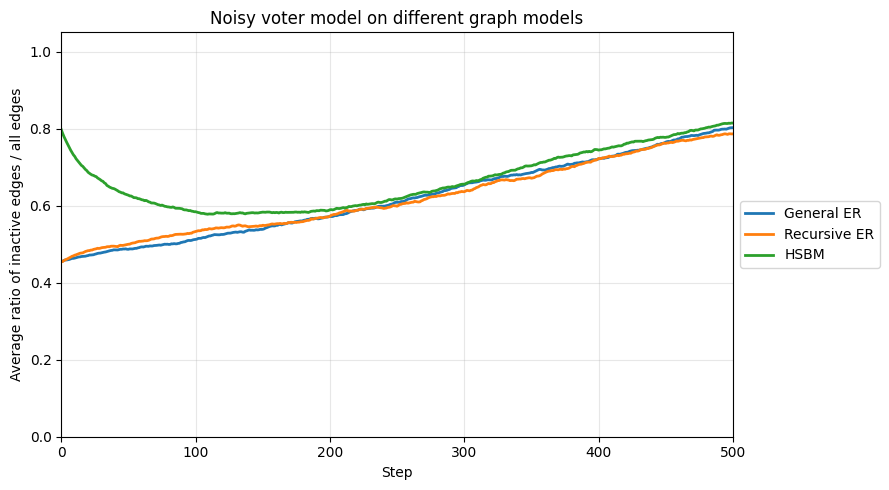

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Noisy voter model on different graph models'}, xlabel='Step', ylabel='Average ratio of inactive edges / all edges'>)

In [12]:
plot_graph_model_comparison_noisy_majority_ratio(results) 
plot_graph_model_comparison_noisy_inactive_edge_ratio(results)